Imports

In [1]:
from simulated_annealing import *
from data_generator import *
from data_loader import *
from annealing_helpers import *
from timetable_phase import *
import matplotlib.pyplot as plt

# Example usage of generator, loader and simulated annealing

### Data generation

In [2]:
stops = 5
time_windows = 24

generate_dummy_data(stops, time_windows)

### Loading the data

In [4]:
P, W = load_data_as_matrices("data/input/travel_times.csv", stops, time_windows)

### Building data

In [5]:
C = 40
R = 30
ALPHA = 1.0
BETA = 30.0
data = build_problem_data(P, C, R, alpha=ALPHA, beta=BETA)

### Running simulated annealing

In [6]:
initial_temp = 10.0
min_temp = 1e-3
cooling_rate = 0.999
max_iter = 1000
log_every = 10

results = run_schedule_optimization(data, initial_temp, min_temp, cooling_rate, max_iter, log_every)

### Interpreting the results

In [7]:
print_results(results)

                 --- Annealing Results ---

           Initial frequencies:   Hourly demands:   Best solution:
Hour: 0          Freq: 1          Demand: 10          Freq: 0
Hour: 1          Freq: 1          Demand: 10          Freq: 1
Hour: 2          Freq: 1          Demand: 11          Freq: 0
Hour: 3          Freq: 1          Demand: 12          Freq: 2
Hour: 4          Freq: 6          Demand: 201          Freq: 2
Hour: 5          Freq: 5          Demand: 182          Freq: 2
Hour: 6          Freq: 12          Demand: 466          Freq: 6
Hour: 7          Freq: 11          Demand: 413          Freq: 5
Hour: 8          Freq: 13          Demand: 509          Freq: 6
Hour: 9          Freq: 5          Demand: 166          Freq: 2
Hour: 10          Freq: 4          Demand: 126          Freq: 2
Hour: 11          Freq: 4          Demand: 126          Freq: 2
Hour: 12          Freq: 4          Demand: 143          Freq: 2
Hour: 13          Freq: 4          Demand: 155          Freq: 2
Hour

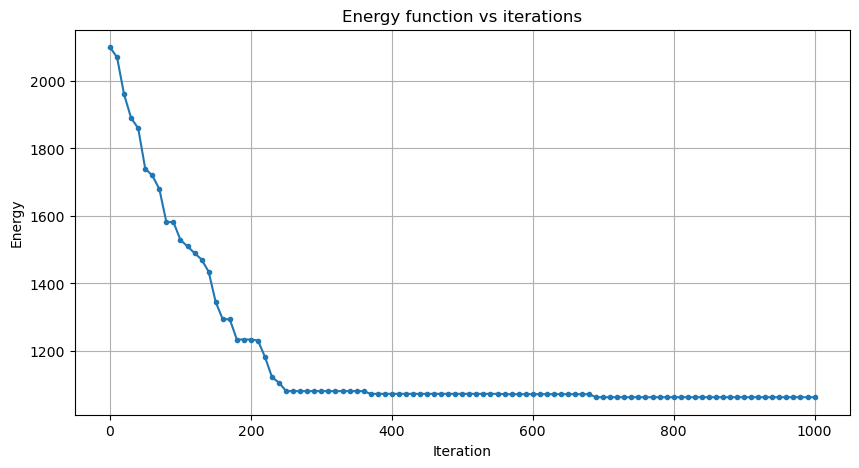

In [8]:
xs, ys = zip(*results["log"])
plt.figure(figsize=(10, 5))
plt.plot(xs, ys, '.-')
plt.xlabel('Iteration')
plt.ylabel('Energy')
plt.title('Energy function vs iterations')
plt.grid(True)
plt.show()

In [9]:
timetable_df = generate_timetable(results, W)

In [10]:
print("\nGotowy rozkład jazdy (wycinek pierwszych 15 odjazdów):")
        # Wyświetlamy ładnie w konsoli bez indeksów
print(timetable_df.head(40).to_string(index=False))

# 4. Zapis do pliku CSV
os.makedirs("data/output", exist_ok=True)
output_file = "data/output/final_timetable.csv"
timetable_df.to_csv(output_file, index=False)
print(f"\n✅ Sukces! Pełny rozkład zapisano pomyślnie do pliku: {output_file}")


Gotowy rozkład jazdy (wycinek pierwszych 15 odjazdów):
 TripID  Stop  DepartureTime_Min ClockTime  HourWindow
      1     1               90.0     01:30           1
      1     2               94.0     01:34           1
      1     3               96.0     01:36           1
      1     4              101.0     01:41           1
      1     5              105.0     01:45           1
      2     1              195.0     03:15           3
      2     2              199.0     03:19           3
      2     3              201.0     03:21           3
      2     4              206.0     03:26           3
      2     5              210.0     03:30           3
      3     1              225.0     03:45           3
      3     2              229.0     03:49           3
      3     3              231.0     03:51           3
      3     4              236.0     03:56           3
      3     5              240.0     04:00           3
      4     1              255.0     04:15           4
      4  